#  **SINIFLANDIRMA**

# K - En Yakın Komşu
- K-Nearest Neighbors (KNN), makine öğrenimi alanında sınıflandırma ve regresyon problemlerini çözmek için kullanılan basit ve popüler bir algoritmadır.
- Temelde, bir veri noktasının sınıfını tahmin etmek veya bir değeri öngörmek için en yakın komşuların etrafındaki veri noktalarının etiketlerini veya değerlerini kullanır.

## KNN Akış Şeması
1. Komşu sayısı K'yı seçin
2. K adet komşunun mesafesini hesaplayın
3. Hesaplanan mesafelere göre K en yakın komşuyu seçin
4. Bu K komşulardan her kategorideki veri noktalarının sayısını sayın
5. Yeni veri noktalarını, komşu sayısı maksimum olan kategoriye atayın.

## Mesafe Nedir?
- Euclidean mesafesi
- Manhattan mesafesi
- Minkowski mesafesi
- Hamming mesafesi

## Hiperparametre Optimizasyonu
- Elbow method, KNN gibi kümeleme veya sınıflandırma algoritmalarında K değerini seçmek için kullanılan bir tekniktir.
- Bu yöntem, farklı K değerlerini deneyerek modelin performansını değerlendirir ve optimum K değerini belirlemeye çalışır.
- Elbow methodu, K değerinin artmasıyla birlikte modelin performansındaki azalışın hızının azalması ve eğrinin dirsek gibi bükülmesi prensibine dayanır.
- Bu dirsek noktası, K değerinin en iyi performansı sağladığı noktayı temsil eder.

### KNN
Amaç:
- Bu çalışma, göğüs kanseri veri setini kullanarak KNN algoritması ile sınıflandırma yapmak.
- Modelin doğruluğunu hesaplayalım, farklı K değerleri için doğruluk analizi yani hiperparametre ayarlaması yapalım.

Veri seti hakkında:
- Veri seti: "Breast Cancer Wisconsin (Diagnostic)" sklearn kütüphanesinin içerisinde bulunur.
- 569 sample, 30 features
- hedef: 2 sınıftan oluşur.
  - 0 -> kötü huylu tümör
  - 1 -> iyi huylu tümör
- features: hücre çekirdeği özellikleri (yarıçap, doku pürüzsüzlüğü, yoğunluk vb.)

Program / akış:
1. Veri setini yükle ve incele
2. Özellik (features) ve hedef (target) değişkenlerin ayrılması
3. Eğitim ve test verilerinin oluşturulması
4. Özniteliklerin ölçeklendirilmesi (standardizasyon)
5. KNN sınıflandırıcının eğitilmesi ve test edilmesi
6. Doğruluk oranı ve confusion matrisin hesaplanması
7. Hiperparametre ayarlaması
8. Sonuçların grafiksel olarak gösterilmesi

In [ ]:
# gerekli olan kütüphanelerin içeri aktarılması
from sklearn.datasets import load_breast_cancer # veri seti
from sklearn.neighbors import KNeighborsClassifier # KNN sınıflandırıcısı
from sklearn.metrics import accuracy_score, confusion_matrix # değerlendirme metrikleri
from sklearn.model_selection import train_test_split # veri setini eğitim ve test veri seti olarak 2 ye ayırır.
from sklearn.preprocessing import StandardScaler # ölçeklendirme

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 1 - veri seti yükle ve incele
cancer = load_breast_cancer()
df = pd.DataFrame(data = cancer.data, columns = cancer.feature_names)
df['target'] = cancer.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# 2 - feature ve hedef değişkenlerin ayrılması
X = cancer.data
y = cancer.target

In [ ]:
# 3 - train test ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# 4 - ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 5 - KNN sınıflandırıcı tanımla ve eğit
knn = KNeighborsClassifier(n_neighbors=3) # k=3
knn.fit(X_train, y_train) # eğitim

KNeighborsClassifier(n_neighbors=3)

In [ ]:
# 6 - doğruluk ve confusion matris
y_pred = knn.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9590643274853801

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[ 59,   4],
       [  3, 105]])

In [ ]:
# 7 - 8 hyperparameter tuning
accuracy_values = []
k_values = []
for k in range(1,21):
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)
  y_pred = knn.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  accuracy_values.append(accuracy)
  k_values.append(k)

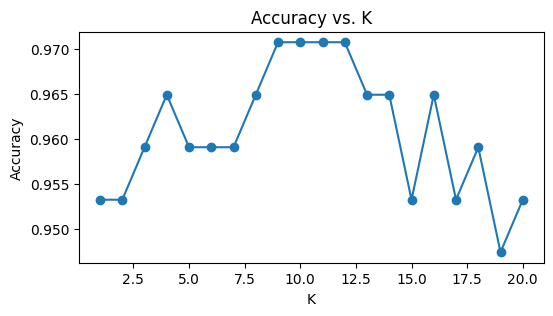

In [ ]:
plt.figure(figsize = (6,3))
plt.plot(k_values, accuracy_values, marker='o', linestyle = "-")
plt.title("K değerine karşılık gelen accuracy")
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. K')
plt.show()

# Karar Ağaçları
- Karar ağaçları, ağaç yapısı şeklindeki bir dizi karar kuralıyla veri kümesinin bölerek hedef değişkenin tahmin edilmesini sağlar.
- Karar ağacı, hem sınıflandırma hem de regresyon görevleri için kullanılan parametrik olmayan bir denetimle öğrenme algoritmasıdır.
- Bu algoritma, kök düğüm, dallar, iç düğümler ve yaprak düğümlerinden oluşan hiyerarşik bir ağaç yapısına sahiptir.

## Karar Ağaçları Türleri
- ID3 (Iterative Dichotomiser 3)
  - Bu algoritma, aday bölünmeleri değerlendirmek için entropi ve bilgi kazancını kullanır.
- C4.5
  - ID3'ün sonraki bir versiyonu olarak kabul edilir.
  - Karar ağaçlarında bölme noktalarını değerlendirmek için bilgi kazancı veya kazanç oranlarını kullanabilir.
- CART (Sınıflandırma ve regresyon ağaçları)
  - Bu algoritma genellikle ideal bölünme özelliğini belirlemek için Gini karışıklığını kullanır.
  - Gini karışıklığı, rastgele seçilen bir özelliğin ne sıklıkla yanlış sınıflandırıldığını ölçer.
  - Gini karışıklığını kullanarak değerlendirirken, daha düşük bir değer daha idealdir.

## Bilgi Kazancı (Information Gain)
- Bir özelliğin bölünme noktasının ne kadar iyi olduğunu belirlemek için kullanılır.
- Özü, bir özelliğin seçilmesinin, veri kümesinin ne kadar iyi sınıflandırılacağına dair belirsizliği azaltıp azaltmadığını ölçmektir.
- Yani, bir özellik seçildiğinde, yeni oluşan alt kümelerin daha homojen olup olmadığını değerlendirir.
- Bilgi kazancı ne kadar yüksekse, bir özellik o kadar iyi bir bölünme kriteri olarak kabul edilir.

## Entropi
- Karar ağaçları (decision trees) içinde entropi, belirli bir düğümdeki veri noktalarının sınıflarının ne kadar karışık olduğunu ölçen bir metriktir.
- Daha düşük bir entropi değeri, bir düğümün daha homojen sınıflara sahip olduğunu, yani veri noktalarının çoğunluğunun aynı sınıfa ait olduğunu gösterir.
- Daha yüksek bir entropi değeri ise, bir düğümün daha karışık sınıflara sahip olduğunu, yani veri noktalarının farklı sınıflara daha eşit olarak dağıldığını gösterir.

## Gini Impurity
- Gini belirsizliği, bir başka karar ağacı algoritması olan CART tarafından kullanılan bir ölçümdür.
- Bir düğümdeki veri noktalarının farklı sınıflara dağılımının ne kadar karışık olduğunu ölçer.
- Gini karışıklığı, 0 ile 0.5 arasında bir değer alır, 0 en saf durumu (yani tüm veri noktalarının aynı sınıfa ait olduğu durumu), 0.5 ise en karışık durumu ifade eder.
- Bir düğümün Gini karışıklığı ne kadar düşükse, o kadar homojen sınıflara sahip olur ve böylece daha iyi bir bölünme kriteri olarak kabul edilir.

## Karar Ağaçları Hiperparametreleri
- Maksimum Derinlik (max_depth)
- Minimum Bölme Boyutu (min_samples_split)
- Minimum Yaprak Boyutu (min_samples_leaf)
- Maksimum Özellikler (max_features)
- Bölünme Kriteri (criterion)
- Bu hiperparametrelerin ayarlanması için Kapsamlı Arama ve Çapraz Doğrulama gibi yöntemler kullanılmaktadır.

## Karar Ağaçları (Decision Trees)
Amaç:
- Iris veri seti kullanarak Karar Ağacı sınıflandırıcısı eğitmek, model performansının değerlendirmek ve karar ağacını görselleştirmek.

Program/ Akış Şeması:
1. Veri setini yüklemek
2. Eğitim ve test verisini ayırma
3. Karar ağacı modelini oluştur ve eğit
4. Test verisi ile doğrulama yap
5. Karar ağacını ve öznitelik önemini görselleştir

In [ ]:
# gerekli olan kütüphanelerin içeriye aktarılması
from sklearn.datasets import load_iris # 4 features, 3 hedef etiket
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
# 1 - veri seti yükler
iris = load_iris()
df = pd.DataFrame(data = iris.data, columns = iris.feature_names)
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
X = iris.data # features
y = iris.target # target

In [ ]:
# 2 - train ve test ayrımı
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [ ]:
# 3 - karar ağacı oluşturulması ve eğitilmesi
dt = DecisionTreeClassifier(criterion = "gini",max_depth=3,random_state=42)
dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
# 4 - dt değerlendirme test
y_pred = dt.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
accuracy

1.0

In [ ]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test,y_pred)
conf_matrix

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

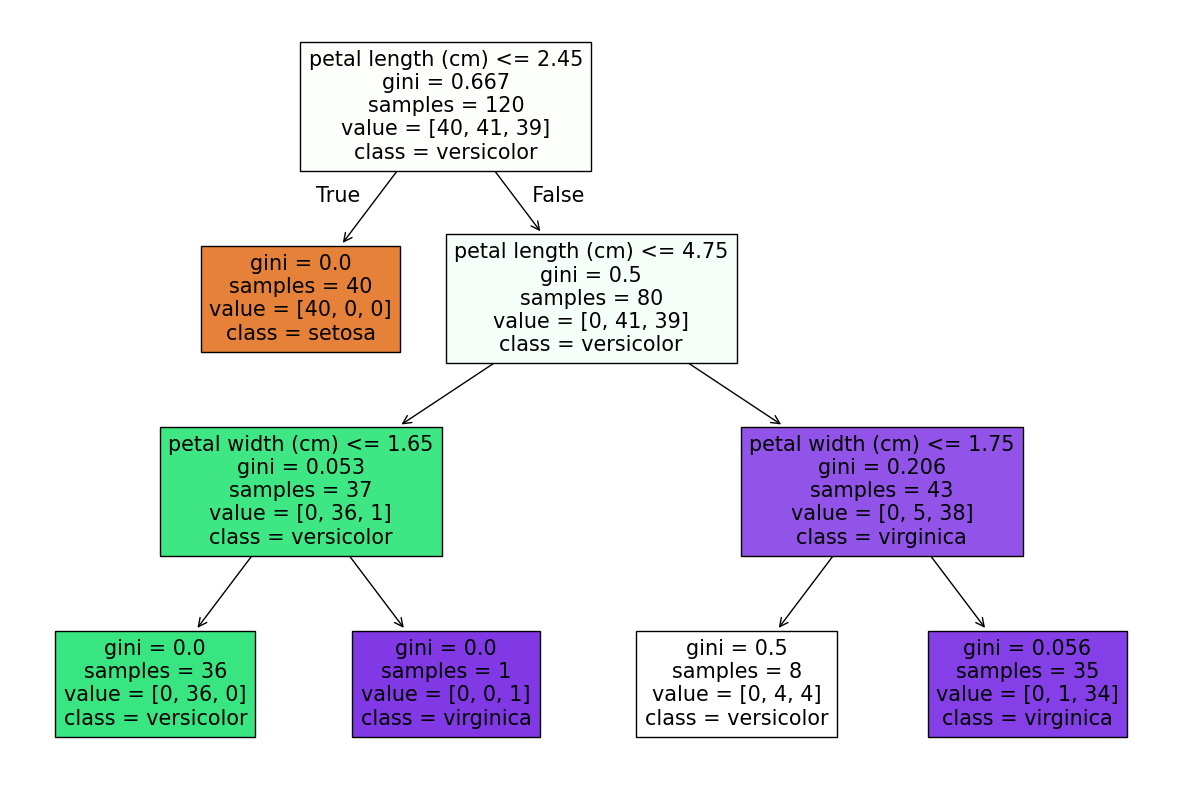

In [ ]:
# 5 - karar ağacı görselleştirme
plt.figure(figsize = (15,10))
plot_tree(dt,filled=True,feature_names=iris.feature_names,class_names=list(iris.target_names))
plt.show()

In [ ]:
# feature importance (öznitelik önemi) - feature selection
feature_importances = dt.feature_importances_
feature_names = iris.feature_names
feature_importances_sorted = sorted(zip(feature_importances,feature_names),reverse=True)
for importance, feature_name in feature_importances_sorted:
  print(f"{feature_name}: {importance}")

petal length (cm): 0.9346263239452668
petal width (cm): 0.06537367605473333
sepal width (cm): 0.0
sepal length (cm): 0.0


# Random Forest
- Rastgele ormanlar, birden çok karar ağacının bir araya gelerek bir orman oluşturduğu bir topluluk öğrenme yöntemidir.
- Her karar ağacı, farklı alt örneklem (bootstrap sample) veya alt özellikler (random subset of features) kullanılarak eğitilir.

## Rastgele Orman Türleri
- Sınıflandırma için Rasgele Ormanlar
- Regresyon için Rasgele Ormanlar

## Rastgele Orman Hiperparametreleri
- Ağaç Sayısı (n_estimators)
- Özelliklerin Sayısı (max_features)
- Ağaç Derinliği (max_depth)
- Örnekleme Oranı (bootstrap)

## Rastgele Orman
Amaç:
- Olivetti Faces veri seti ile yüz tanıma (face recognition) probleminde Random Forest algoritmasını kullanarak sınıflandırma yapmak ve modelin doğruluğunu değerlendirmek

Akış şeması:
1. Olivetti faces veri seti yüklenmesi
2. Olivetti faces veri seti görselleştirme

3. Eğitim ve test verisini ayır
4. Random Forest modelini eğit
5. Doğruluk skorunu (accuracy) hesapla

In [6]:
# gerekli kütüphanelerin içeriye aktarılması
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

In [7]:
# 1 - olivetti veri setinin yüklenmesi
oli = fetch_olivetti_faces()
X = oli.data #features
y = oli.target #hedef değişken

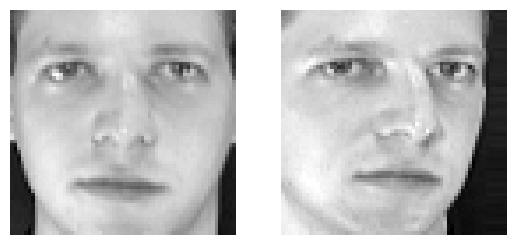

In [8]:
# 2 - veri seti görselleştirme
plt.figure()
for i in range(2):
  plt.subplot(1,2,i+1)
  plt.imshow(oli.images[i],cmap='gray')
  plt.axis("off")

plt.show()

In [9]:
# 3 - eğitim ve test verisini ayır
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
# 4 - random forest modeli eğit
rd = RandomForestClassifier(n_estimators=100,random_state=42)
rd.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [13]:
# 5 - evaluation değerlendirme - accuracy
y_pred = rd.predict(X_test)
accuracy = accuracy_score(y_pred,y_test)
accuracy

0.9375